# Task 2: Weight Initialization & Gradient Vanishing Diagnostic

See how different initial weight sizes affect signal propagation through 10 deep layers.

In [1]:
import torch
import matplotlib.pyplot as plt

torch.manual_seed(42)

### 1. Pass Random Input through 10 Deep Layers under 3 Initializations

In [2]:
# Initializations to test
scales = {'Too Small (0.01)': 0.01, 'Too Large (2.0)': 2.0, 'Kaiming He (Correct)': (2.0 / 50)**0.5}
results = {}

for name, scale in scales.items():
    x = torch.randn(100, 50)  # Input batch of 100 samples
    layer_stds = []

    for layer in range(10):
        W = torch.randn(50, 50) * scale  # Weight matrix
        x = torch.relu(x @ W)             # Forward step
        layer_stds.append(x.std().item()) # Measure variation size

    results[name] = layer_stds

### 2. Plot Activation Sizes Across Layer Depth

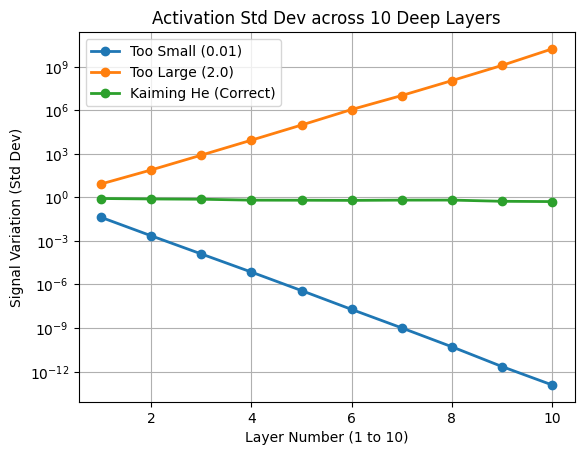

In [3]:
for name, stds in results.items():
    plt.plot(range(1, 11), stds, label=name, marker='o', lw=2)

plt.title('Activation Std Dev across 10 Deep Layers')
plt.xlabel('Layer Number (1 to 10)')
plt.ylabel('Signal Variation (Std Dev)')
plt.yscale('log')
plt.legend()
plt.grid(True)
plt.show()